# Part 4: Exploratory Data Analysis of Weather Dataset

## 4.0) Imports and loading the training set
The training set is located in the `processed/` folder.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv('..\\data\\processed\\weather_data_train.csv')

## 4.1) Distribution of Target (`day_type`)
The column `day_type` represents the class column of this dataset. The possible values are `Sunny`, `Cloudy`, `Cold`, and `Rainy`. `Sunny` is the class with the most instances, while `Hot` has the fewest.

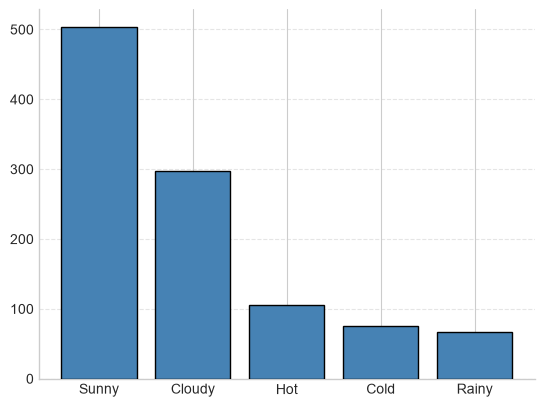

In [2]:
day_type_counts = df['day_type'].value_counts()

plt.bar(day_type_counts.index, day_type_counts.values, color='steelblue', edgecolor='black', zorder=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

The following is a box plot of the humid and non-humid days. Humid days are those whose `humidity` value is above `0.5`, while non-humid days are those whose `humidity` value is equal to or less than `0.5`.

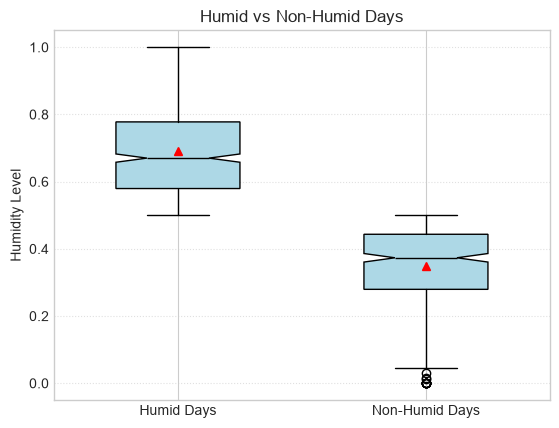

In [3]:
humid_df = df[df['humidity']>0.5]['humidity']
non_humid_df = df[df['humidity']<=0.5]['humidity']
plt.boxplot([humid_df, non_humid_df], notch=True, patch_artist=True, showmeans=True,
            tick_labels=['Humid Days', 'Non-Humid Days'], widths=0.5,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='black'),
            meanprops=dict(markerfacecolor='red', markeredgecolor='red'))
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.ylabel('Humidity Level')
plt.title('Humid vs Non-Humid Days')
plt.show()

## 4.2) Correlation Heatmap
This heatmap shows, generally, the correlation between the five features. The most notable correlations are between `day_temp` and `uv_index`.

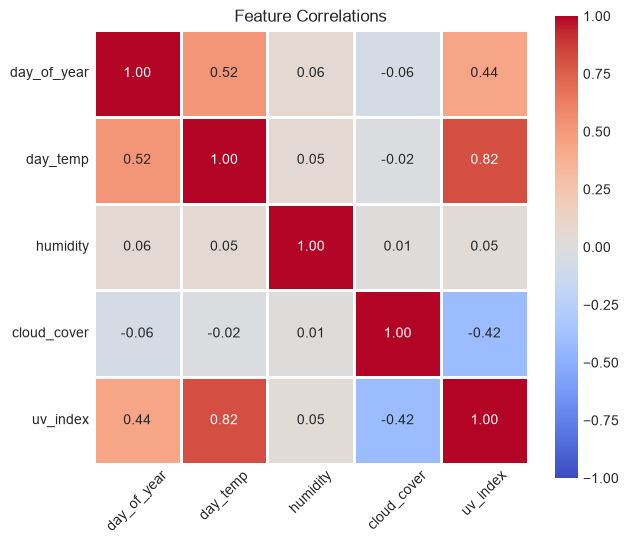

In [4]:
plt.figure(figsize=(7, 6))
df_map = df.corr(numeric_only=True)
sns.heatmap(df_map, linewidths=1, linecolor='white', annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Feature Correlations')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()

## 4.3) Scatter Plot
Here is a scatter plot of the noted correlation above, `day_temp` and `uv_index`.

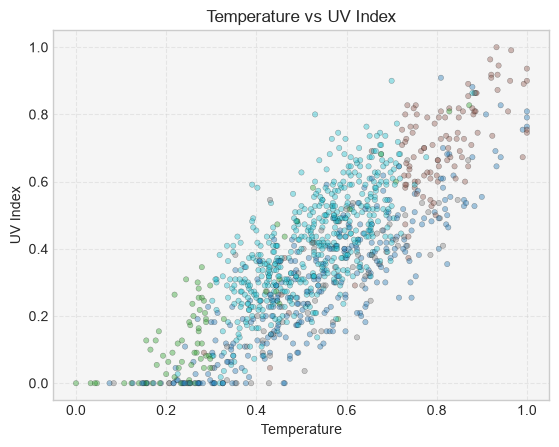

In [5]:
plt.scatter(df['day_temp'], df['uv_index'], alpha=0.4, s=15,
            edgecolors='black', linewidths=0.3,
            c=df['day_type'].astype('category').cat.codes, cmap='tab10')
plt.xlabel('Temperature')
plt.ylabel('UV Index')
plt.gca().set_facecolor('#f5f5f5')
plt.grid(linestyle='--', alpha=0.4)
plt.title('Temperature vs UV Index')
plt.show()

## 4.5) Trend over Time
We briefly ordinate the class column for this task, with sunnier and warmer days being higher, while rainier and colder days are lower.

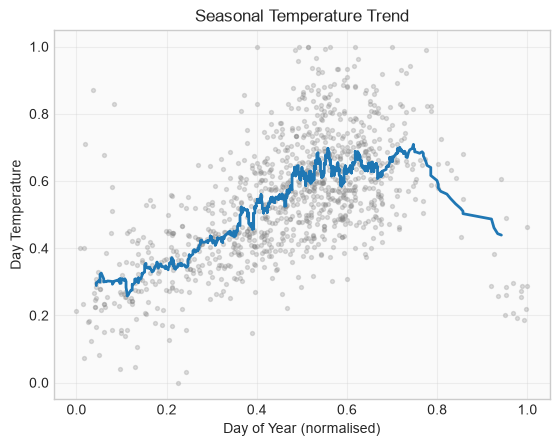

In [6]:
s = df.sort_values("day_of_year")
plt.scatter(s["day_of_year"], s["day_temp"], s=8, alpha=0.25, color="grey")
plt.plot(s["day_of_year"], s["day_temp"].rolling(30, center=True).mean(), linewidth=2)
plt.gca().set_facecolor('#fafafa')
plt.grid(alpha=0.3)
plt.xlabel('Day of Year (normalised)')
plt.ylabel('Day Temperature')
plt.title('Seasonal Temperature Trend')
plt.show()